# 第四章 PyTorch深度神经网络

深度学习是当下热门的机器学习研究方向，它是使用深层架构的机器学习方法，已经广泛应用于人工智能所涉及的众多领域，例如语音识别、计算机视觉、自然语言、在线广告等，作为深度学习框架的PyTorch可以在该领域中大展宏图。本章将介绍PyTorch在深度神经网络中的应用。

## 4.1 神经网络概述

神经网络的概念最初来源于生物学家对大脑神经网络的研究，从中发现其神经元的工作原理，并且从数学角度提出感知器模型，并对其进行抽象化。本节介绍神经网络的基础知识。

### 4.1.1 神经元模型

神经元模型是1943年，由心理学家Warren McCulloch和数理逻辑学家Walter Pitts在合作的《A logical calculus of the ideas immanent in nervous activity》论文中提出，并给出了人工神经网络的概念及人工神经元的数学模型，从而开创了人工神经网络研究的时代。

在神经网络中，神经元处理单元可以表示不同的对象，例如特征、字母、概念或者一些有意义的抽象模式。网络中处理单元的类型分为3类:输入单元、输出单元和隐单元。输入单元接收外部世界的信号与数据;输出单元实现系统处理结果的输出;隐单元是处在输入和输出单元之间，不能由系统外部观察的单元。神经元间的连接权值反映了单元间的连接强度，信息的表示和处理体现在网络处理单元的连接关系中。

神经网络是一种模仿生物神经网络的结构和功能的数学模型或计算模型，它是由大量的节点(即神经元)和之间的相互连接构成的，每个节点代表一种特定的输出函数，称为激励函数，每两个节点间的连接都代表一个对于通过该连接信号的加权值，称之为权重。神经元是神经网络的基本元素，如下图所示。

![](data/img1.jpeg)

图中是$x_1···x_n$从其他神经元传来的输入信号，$w_{ij}$表示从神经元$j$到神经元$i$的连接权值，$\theta$表示一个阈值，或称为偏置，则神经元$i$的输出与输入的关系表示为:$net_i=\sum_{j=1}^nw_{ij}x_j-\theta$,$y_i = f(net_i)$。

其中$y_i$表示神经元$i$的输出，函数$f$称为激活函数，$net_i$称为净激活。若将阈值看成是神经元$i$的一个输入$x_0$的权重$w_{i0}$，则上面的式子可以简化为:$net_{i}=\sum_{j=0}^nw_{ij}x_j$, $y_i = f(net_i)$。

若用$X$表示输入向量，用$W$表示权重向量，即:$X=[x_0,x_1,···,x_n]$, $W = [w_{i0}, w_{i1}, w_{i2},···，w_{in}]^T$，则神经元的输出可以表示为向量相乘的形式：$net_i=XW$, $y_i=f(net_i)=f(XW)$。

如果神经元的净激活为正，则称该神经元处于激活状态或兴奋状态，如果净激活为负，则称该神经元处于抑制状态。

### 4.1.2 多层感知机

多层感知器是一种前向结构的人工神经网络，映射一组输入向量到一组输出向量。MLP可以认为是一个有向图，由多个节点层组成，每一层全连接到下一层。除了输入节点外，每个节点都是一个带有非线性激活函数的神经元(或称处理单元)。

一种被称为反向传播算法的监督学习方法常被用来训练MLP,MLP是感知器的推广，克服了感知器不能对线性不可分数据进行识别的弱点。若每个神经元的激活函数都是线性函数，则任意层数的MLP都可以被简化成一个等价的单层感知器。

实际上，MLP本身可以使用任何形式的激活函数，譬如阶梯函数或逻辑S形函数(Logistic Sigmoid Function)，但为了使用反向传播算法进行有效学习，激活函数必须限制为可微函数。由于具有良好的可微性，很多S形函数，尤其是双曲正切函数(Hy-perbolic Tangent)及逻辑S形函数，被采用为激活函数。

常被MLP用来进行学习的反向传播算法在模式识别的领域中是标准监督学习算法，并在计算神经学及并行分布式处理领域中持续成为被研究的课题。MLP已被证明是一种通用的函数近似方法，可以被用来拟合复杂的函数，或解决分类问题。

MLP在80年代的时候曾是相当流行的机器学习方法，拥有广泛的应用场景，譬如语音识别、图像识别、机器翻译等，但自90年代以来，MLP遇到来自更为简单的支持向量机的强劲竞争。由于深层学习的成功，MLP又重新得到了关注。

多层感知器模型如下图所示：

![](data/img2.jpeg)

隐藏层神经元的作用是从样本中提取样本数据中的内在规律模式并保存起来，隐藏层每个神经元与输入层都有边相连，隐藏层将输入数据加权求和，并通过非线性映射作为输出层的输入，通过对输入层的组合加权及映射找出输入数据的相关模式，而且这个过程是通过误差反向传播自动完成的。

当隐藏层节点太少的时候，能够提取以及保存的模式较少，获得的模式不足以概括样本的所有有效信息，得不到样本的特定规律，导致识别同样模式新样本的能力较差，学习能力较差。

当隐藏层节点个数过多时，学习时间变长，神经网络的学习能力较强，能学习较多输入数据之间的隐含模式。但是一般来说，输入数据之间与输出数据相关的模式个数未知，当学习能力过强时，有可能把训练输入样本与输出数据无关的非规律性模式学习进来，而这些非规律性模式往往大部分是一些样本噪声，这种情况叫作过拟合(Over Fitting)。过拟合是记住了过多和特定样本相关的信息，当新来样本含有相关模式但是很多细节并不相同时，预测性能并不是太好，降低了泛化能力。这种情况的表现往往是在训练数据集上误差极小，测试数据集上误差较大。

具体隐藏层神经元个数的多少取决于样本中蕴含规律的个数以及复杂程度，而样本蕴含规律个数往往和样本数量有关系。确定网络隐藏层参数的一个办法是将隐藏层个数设置为超参，使用验证集验证，选择在验证集中误差最小的作为神经网络的隐藏层节点个数。还有就是通过简单的经验设置公式来确定隐藏层神经元个数:$l=\sqrt {m+n} + \alpha$, 其中，$l$是隐藏层节点个数，$m$是输入层节点个数，$n$是输出层节点个数，$\alpha$般是1~10的常数。

### 4.1.3 前馈神经网络

不同的人工神经网络有着不同网络连接的拓扑结构，比较直接的拓扑结构是前馈网络，它是最早提出的多层人工神经网络。在前馈神经网络中，每一个神经元分别属于不同的层，每一层神经元可以接收前一层神经元的信号，并产生信号输出到下一层神经元。第0层神经元叫输入层，最后一层神经元叫输出层，其他处于中间层次的神经元叫隐藏层。

在前馈神经网络(Feedforward Neural Network, FNN)中，每一层的神经元可以接收前一层神经元的信号，并产生信号输出到下一层。整个网络中无反馈，信号从输入层向输出层单向传播。前馈神经网络通过下面的公式进行信息传播:$z^{(l)}=W^{(l)}·a^{(l-1)}+b^{(l)}$, $a^{(l)}=f_l(z^{(l)})$,其中：
* $l$:表示神经网络的层数。
* $m^{(l)}$:表示第$l$层神经元的个数。 
* $f_l(·)$:表示$l$层神经元的激活函数。
* $W^{(l)}\in R^{m^{(l)}\times m^{(l-1)}}$:表示$l-1$层到第$l$层的权重矩阵。
* $b^{(l)}\in R^{m^{(l)}}$:表示$l-1$层到第$l$层的偏置。
* $z^{(l)}\in R^{m^{(l)}}$:表示第$l$层的净输入。
* $a^{(l)}\in R^{m^{(l)}}$:表示第$l$层的输出。
这样前馈神经网络通过逐层的信息传递得到网络最后的输出。整个网络可以看为一个复合函数，将向量$X$作为第1层的输入$a_0$，将第$L$层的输出$a^{(l)}$作为整个函数的输出。$a^{(l)=\Phi(X,W,b)}$

## 4.2 卷积神经网络

卷积神经网络(Convolutional Neural Network, CNN)是一类包含卷积计算且具有深度结构的前馈神经网络，它是深度学习框架中的代表算法之一。本节介绍卷积神经网络的基础知识。

### 4.2.1 卷积神经网络的历史

卷积神经网络最早可以追溯到1943年，心理学家Warren和数理逻辑学家Walter 在论文中第一次提出神经元的概念，通过一个简单的数学模型将神经反应简化为信号输入、求和、线性激活及输出，具有开创性意义;1958年，神经学家Frank通过机器模拟了人类的感知能力，这就是最初的“感知器”，同时他在当时的IBM704型电子数字计算机上完成了感知器的仿真，能够对三角形和四边形进行分类，这是神经元概念提出后第一次成功的实验，验证了神经元概念的可行性。以上是神经元发展的第一阶段。第一代神经网络由于结构单一，仅能解决线性问题。此外，认知的限制也使得神经网络的研究止步于此。

第二代卷积神经网络出现于1985年，Geoffrey Hinton在神经网络中使用多个隐含层进行权重变换，同时提出了误差反向传播( Backpropagation, BP)算法，求解各隐含层的网络参数，优点是理论基础牢固、通用性好，不足之处在于网络收敛速度慢，容易出现局部极小的问题;1988年，Wei Zhang提出了平移不变人工神经网络(Shift-Invariant Artificial Neural Network, SIANN),将其应用于医学图像检测领域;1989年，LeCun构建了应用于计算机视觉问题的卷积神经网络，也就是LeNet的早期版本，包含两个卷积层、两个全连接层，共计6万多个参数，结构上与现代的卷积神经网络模型结构相似，而且开创性地提出了“卷积”这一概念，卷积神经网络因此得名。1998年，LeCun构建了更加完备的卷积神经网络LeNet-5，并将其应用于手写字体识别，在原有LeNet的基础上加入了池化层，模型在Mnist数据集上的识别准确率达到了98%以上，但由于当时不具备大规模计算能力的硬件条件，因此卷积神经网络的发展并没有引起足够的重视。

第三代卷积神经网络兴起于2006年，统称为深度学习，分为两个阶段，2006至2012年为快速发展期，2012至今为爆发期，训练数据量越大，卷积神经网络准确率越高，同时随着具备大规模计算能力GPU的应用，模型的训练时间大大缩短，深度卷积神经网络的发展是必然的趋势。2006年，Hintont提出了包含多个隐含层的深度置信网络(Deep Belief Network, DBN)，取得了十分好的训练效果，DBN的成功实验拉开了卷积神经网络百花齐放的序幕:自2012年AlexNet取得ImageNet视觉挑战赛的冠军，几乎每年都有新的卷积神经网络产生，诸如ZFNet、VGGNet、Goog-LeNet、ResNet以及DPRSNet等，都取得了很好的效果。

### 4.2.2 卷积神经网络的结构

卷积神经网络中隐含层低层中的卷积层与池化层交替连接，构成了卷积神经网络的核心模块，高层由全连接层构成。

1.卷积层

卷积层用于提取输入的特征信息，由若干卷积单元组成，每个卷积单元的参数都是通过反向传播算法优化得到的，通过感受野(Filter)对输入图片进行有规律地移动，并与所对应的区域做卷积运算提取特征。低层卷积只能提取到低级特征，如边缘、线条等;高层卷积可以提取更深层的特征。

卷积层参数包括感受野大小、步长(Stride)和边界填充( Padding)，三者共同决定了卷积层输出特征图的尺寸大小;感受野大小小于输入图片尺寸，感受野越大，可提取的特征越复杂;步长定义了感受野扫过相邻区域时的位置距离;边界填充是在特征图周围进行填充，避免输出特征丢失过多边缘信息的方法，Pad值代表填充层数。

2.激活层

卷积运算提取到的图像特征是线性的，但真正的样本往往是非线性的，为此引入了非线性函数来解决。激活函数使得每个像素点可以用0~1的任何数值来代表，以模拟更为细微的变化。激活函数一般具有非线性、连续可微、单调性等特性。比较常用的激活函数有Sigmod函数、Tanh函数以及ReLU函数。

3.池化层

池化层的作用为压缩特征图、提取主要特征、简化网络计算的复杂度。池化方式一般有两种:均值池化与最大池化，如下图所示:

![](data/img3.jpeg)

图中采用一个$2\times2$的感受野，步长为池化层kernel的大小，边界填充为0。最大池化即在$2\times2$的区域中寻找最大值;均值池化则是求每一个$2\times2$区域中的平均值，得到主要特征。一般常用的感受野取值为2,步长为2，池化操作将特征图缩小，有可能影响网络的准确度，但可以通过增加网络深度来弥补。

4. 全连接层

全连接层位于卷积神经网络的最后，给出最后的分类结果。在全连接层中，特征会失去空间结构，展开为特征向量，并把由前面层级所提取到的特征进行非线性组合，得到输出，可用公式表示:$f(x) = W*x+b$

其中，x为全连接层的输入，W为权重系数，b为偏置。全连接层连接所有特征输出至输出层，对于图像分类问题，输出层使用逻辑函数或归一化指数函数输出分类标签。在图像识别问题中，输出层输出为物体的中心坐标、大小和分类。在语义分割中，则直接输出每个像素的分类结果。

### 4.2.3 卷积神经网络的类型

1.AlexNet

AlexNet神经网络赢得了2012年ILSVRC (ImageNet大规模视觉识别挑战赛)的冠军。2012年是CNN首次实现Top5误差率15.4%的一年(Top5误差率是指给定一张图像，其标签不在模型认为最有可能的5个结果中的概率)，第二名使用传统识别方法得到的误差率为26.2%。卷积神经网络在这次比赛的表现震惊了整个计算机视觉界，奠定了卷积神经网络在计算机视觉领域的绝对地位。

AlexNet包含6亿3千万个连接、6000万个参数和65万个神经元， 网络结构如下图所示。

![](data/img4.jpeg)

In [1]:
import torch
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 96, 11, 4),
            nn.ReLU(),
            nn.MaxPool2d(3, 2),
            
            nn.Conv2d(96, 256, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(3, 2),
            
            nn.Conv2d(256, 384, 3, 1, 1),
            nn.ReLU(),
            
            nn.Conv2d(384, 384, 3, 1, 1),
            nn.ReLU(),
            
            nn.Conv2d(384, 256, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(3, 2),
        )
        
        self.fc = nn.Sequential(
            nn.Linear(256*5*5, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )
        
    def forward(self, img):
        feature = self.conv(img)
        output = self.fc(feature.view(img.shape[0], -1))
        return output

In [3]:
alexnet = AlexNet()
img = torch.randn(32, 1, 224, 224)

out = alexnet(img)
print(out.shape)

torch.Size([32, 10])


AlexNet的成功除了深层次的网络结构外，还有以下几点:

首先，采用ReLU作为激活函数，避免了梯度耗散问题，提高了网络训练的速度;其次，通过平移、翻转等扩充训练集，避免产生过拟合;最后提出并采用了LRN(Local Response Normalization,局部响应归一化处理)，利用临近的数据做归一化处理技术，提高深度学习训练时的准确度;除此之外，AlexNet使用GPU处理训练时所产生的大量矩阵运算，提升了网络的训练效率。

2.VGGNet

VGGNet是牛津大学与Google DeepMind公司的研究员一起合作开发的卷积神经网络，2014年取得了ILSVRC比赛分类项目的亚军和识别项目的冠军。VGGNet探索了网络深度与其性能的关系，通过构筑16~19层深的卷积神经网络，Top5误差率为7.5%，在整个卷积神经网络中，全部采用$3\times3$的卷积核与$2\times2$的池化核，网络结构如下图所示。

![](data/img5.png)

VGGNet包含很多级别的网络，深度从11层到19层不等，常用的是VGG-16和VGG-19。VGGNet把网络分成了5段，每段都把多个3x3的网络串联在一起，每段卷积后接一个最大池化层，最后是3个全连接层和一个Softmax层。

![](data/img6.png)

In [3]:
import torch
import torchvision.models as models

model_path = "./data/vgg19-dcbb9e9d.pth"
model = models.vgg19(weights = None)

model.load_state_dict(torch.load(model_path))

img = torch.randn(32, 3, 512, 512)
out = model(img)
print(out.shape)

torch.Size([32, 1000])


VGGNet有两个创新点:

1) 通过网络分段增加网络深度，采用多层小卷积代替一层大卷积，两个$3\times3$的卷积核相当于$5\times5$的感受野，3个相当于$7\times7$的感受野。优势在于:首先包含3个ReLU层，增加了非线性操作，对特征的学习能力更强;其次减少了参数，使用$3\times3$的3个卷积层需要$27\times n$个参数，使用$7\times7$的一个卷积层需要$7\times7 \times n=49\times n$个参数。
2) 在训练过程中采用多尺度和交替训练的方式，同时对一些层进行预训练，使得VGGNet能够在较少的周期内收敛，减轻了神经网络训练时间过长的问题。不足之处在于使用3个全连接层，参数过多导致内存占用过大，耗费过多的计算资源。VGGNet是重要的神经网络，它强调了卷积网络深度的增加对于性能的提升有着重要的意义。

3.GoogleNet

GoogLeNet是由谷歌的研究院提出的卷积神经网络，获得了 2014年的ILSVRC比赛分类任务的冠军，Top5误差率仅为6.656%。GoogLeNet的网络共有22层，但参数仅有700万个，比之前的网络模型都少很多。一般来说，提升网络性能最直接的办法就是增加网络深度，随之增加的还有网络中的参数，但过量的参数容易产生过拟合，也会增大计算量。GoogLeNet采用稀疏连接解决这种问题，为此提出了Inception的结构，如下图所示。

![](data/img7.jpeg)

在Inception结构中，同时采用$1\times1、3\times3、5\times5$卷积核是为了将卷积后的特征保持一致，以便于融合，stride=1, padding分别为0、1、2，卷积后就可以得到相同维度的特征，最后进行拼接，将不同尺度的特征进行融合，使得网络可以更好地提取特征。

在整个网络中，越靠后提取到的特征也越抽象，每个特征所对应的感受野也随之增大。因此，随着层数的增加，$3\times3、5\times5$卷积核的比例也要随之增加，这样会带来巨大的参数计算，为此GoogLeNet有过诸多改进版本，GoogLeNet Inception V2、V3以及V4，通过增加Batch Normalization、在卷积之前采用$1\times1$卷积降低纬度、将$n\times n$的卷积核替换为$1\times n$和$n\times 1$等方法降低网络参数，提升网络性能。

In [8]:
model_path = "./data/googlenet-1378be20.pth"

google_net = models.googlenet(weights = None)
google_net.load_state_dict(torch.load(model_path))

img = torch.randn(32, 3, 96, 96)
out = google_net(img)
print(out.logits.shape)

/opt/anaconda3/envs/pytorch/lib/python3.8/site-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


torch.Size([32, 1000])


4.ResNet

ResNet于2015年被提出，获得了ILSVRC比赛的冠军，ResNet的网络结构有152层，但Top5错误率仅为3.57%，之前的网络都很少有超过25层的，这是因为随着神经网络深度的增加，模型准确率会先上升，然后达到饱和，如果持续增加深度，准确率会下降。随着层数的增多，会出现梯度爆炸或衰减现象，梯度会随着连乘变得不稳定，数值会特别大或者特别小，因此网络性能会变得越来越差。ResNet通过在网络结构中引入残差网络来解决此类问题，残差网络结构如图所示。

![](data/img9.png)

很明显，残差网络是跳跃结构，残差项原本是带权重的，但ResNet用恒等映射代替了它。在上图中，输入为x，期望输出为 H(x)，通过捷径连接的方式将x传到输出作为初始结果，输出为H(x)=F(x)+x，当F(x)=0时，H(x)=X。于是，ResNet相当于将学习目标改变为目标值H(x)和x的差值，也就是所谓的残差F(x)=H(x)-x，因此，后面的训练目标就是将残差结果逼近于0。ResNet通过提出残差学习将残差网络作为卷积神经网络的基本结构，通过恒等映射来解决因网络模型层数过多导致的梯度爆炸或衰减问题，可以最大限度地加深网络，并得到非常好的分类效果。

In [9]:
model_path = "./data/resnet18-5c106cde.pth"

res_net = models.resnet18(weights = None)
res_net.load_state_dict(torch.load(model_path))

img = torch.randn(32, 3, 224, 224)
out = res_net(img)
print(out.shape)

torch.Size([32, 1000])


## 4.3 几种常见的循环神经网络

循环神经网络(Recurrent Neural Network, RNN)又称递归神经网络，它是常规前馈神经网络(Feedforward NeuralNetwork, FNN)的扩展。本节介绍几种常见的循环神经网络。

### 4.3.1 循环神经网络

在传统的神经网络模型中，都是从输入层经过隐藏层，再到输出层，每一层之间的节点都是没有连接的，它们之间没有保存任何状态信息。与此相反，RNN遍历所有序列的元素，每个当前层的输出都与前面层的输出有关，也就是每个层之间的节点是连接的，会将前面层的状态信息保留下来。理论上，RNN应该可以处理任意长度的序列数据，但为了降低一定的复杂度，实践中通常只会选取与前面的几个状态有关的信息。首先简单地介绍RNN的原理，如图所示。

![](data/img10.jpeg)

图中的神经网络由一个神经元组成，x是输入，y是输出，中间有一个箭头表示数据循环更新的是隐藏层，这个就是它实现时间记忆功能的方法。神经网络输入x并产生输出y，最后将输出的结果反馈回去。假设在一个时间t内，神经网络的输入除了来自输入层的x(t)外，还有上一时刻的输出y(t-1)，两者共同输入产生当前层的输出y(t)。我们还可以将这个神经网络按照时间序列形式展开，如下图所示。

![](data/img11.jpeg)

每个神经元的输出都是根据当前的输入x(t)和上一时刻的输出y(t-1)共同决定的。它们所对应的权重是$W_x$和$W_y$，那么，单个神经元的输出计算如下:$y_t = \Phi(x_t^T·W_x+y_{t-1}^T·W_y+b)$。如果将中间的隐藏层展开，就会得到如下图所示的结果

![](data/img12.jpeg)

通常，一个RNN单元在时间t的状态记作$h_t$。U表示此刻输入的权重，W表示前一次输出的权重，V表示此刻输出的权重。在t=1时刻，一般$h_0$表示初始状态为0，随机初始化U、W和V的值， 使用下面的公式计算:$h_1 = f(Ux_1+Wh_0+b_h)$,$O_1 = g(Vh_1+b_o)$

其中，f和g均为激活函数，即那些光滑的曲线函数(非线性函数)，f可以是Sigmoid、ReLU、Tanh等激活函数，g通常是Softmax损失函数，$b_h$是隐藏层的偏置项，$b_o$是输出层的偏置项。前向传播算法在这里就是按照时间t向前推进的，此时的隐藏状态h、是参与到下一个时间的预测过程的，即:$h_1 = f(Ux_2+Wh_1+b_h)$,$O_2 = g(Vh_2+b_o)$。基于上述公式，以此类推，可得到最终的输出公式为:$h_t = f(Ux_t+Wh_{t-1}+b_h)$,$O_t = g(Vh_t+b_o)$

权重共享可以减少运算，使得模型泛化，可以处理连续序列数据的特征，而且不限定序列的长度，仍然能够识别出连续序列在样本中的位置，但不是学习每个位置的规则。这样它不仅能够抓住不同特征之间的连续性，还能减少学习规则。因此，基于权重共享的思想，这里出现的W、U、V以及偏置项都是相等的。前面介绍了关于RNN网络的基本内容，虽然它处理时间序列问题的效果很好，但是简单的RNN网络通常过于简化，仍然存在着一些问题，比如在理论上它应该能够记住更多之前的信息，并可以处理任意长度的序列数据，但实际上却不能形成这种长期记忆，这就是梯度消失问题的一种。梯度消失问题主要是由BP算法和长时间依赖两种原因造成的，而RNN中产生的梯度爆炸问题属于后者，由于时间过长而造成记忆值较小的现象。梯度消失问题主要发生在前馈神经网络(也就是非循环网络)中，随着网络层数的增加，网络最终会变得无法训练。

如果从导数角度来讲，梯度消失就是对激活函数求导，若导数值小于1，则随着网络层数的增多，最终的梯度更新将以指数形式衰减。然而也存在一些反例，比如对激活函数求导，如果导数值大于1，那么随着层数的增大，最终求出的梯度更新将以指数形式增大，导致网络不稳定，使得算法无法收敛。这就是RNN存在的另一种问题一一梯度爆炸。对于这些存在的问题，研究者提出了很多改进的算法，常见的主要有两种:LSTM和GRU.

### 4.3.2 长短期记忆网络

为了解决梯度消失等问题，Hochreiter等人提出了新的RNN架构长短期记忆(Long Short-Term Memory, LSTM)算法，之后Alex Graves、HasIMSak和 Wojciech Zaremba等人逐步改进了该模型。一个基本的LSTM单元结构如图所示。

![](data/img13.png)

LSTM(Long Short-Term Memory)也称长短记忆结构，它是传统RNN的变体，与经典RNN相比能够有效捕捉长序列之间的语义关联，缓解梯度消失或者爆炸现象，同时LSTM的结构更复杂，他的核心结构可以分为四个部分去解析，包括遗忘门，输入门，细胞状态和输出门。

1. 遗忘门结构分析

与传统RNN的内部结构计算非常相似，首先将当前时间步输入$x_t$与上一个时间步隐含状态$h_{t-1}$拼接得到$[x_t, h_{t-1}]$，然后通过一个全连接层做变换，最后通过sigmoid函数进行激活得到$f_t$，我们可以将$f_t$看做是门值，好比一扇门开合的大小程度，门值都将作用在通过该扇门的张量，遗忘门门值将作用在上一层的细胞状态上，代表遗忘过去的多少信息，又因为遗忘门门值是由$x_t$, $h_{t-1}$计算得到的，因此整个公式意味着根据当前时间步输入和上一个时间步隐含状态$h_{t-1}$来决定遗忘多少上一层的细胞状态所携带的过往信息, 公式如下：$f_t = \sigma(W_f·[h_{t-1}, x_t]+b_f)$

2. 输入门结构分析

我们看到输入门的计算公式有两个，第一个就是产生输入门门值的公式，它和遗忘门公式几乎相同，区别在于它们之后要作用的目标上，这个公式意味着输入信息有多少需要进行过滤，输入门的第二个公式是与传统RNN的内部结构计算相同。对于LSTM来讲，它得到的是当前细胞状态，而不是像经典RNN一样得到的是隐含状态。$i_t = \sigma(W_i·[h_{t-1},x_t]+b_i)$,$\hat C_t=tanh(W_C·[h_{t-1},x_t] + b_C)$

3. 细胞状态跟新分析

细胞更新的结构与计算公式非常容易理解，这里没有全连接层，只是将刚刚得到的遗忘门门值与上一时间步得到的$C_{t-1}$相乘，再加上输入门门值与当前时间步得到的未更$\hat C_t$相乘的结果。最终得到更新后的$C_t$作为下一个时间步输入的一部分。整个细胞状态更新过程就是对遗忘门和输入门的应用。$C_t = f_t·C_{t-1}+i_t·\hat C_t$

4. 输出门结构分析

输出门的公式也是两个，第一即是计算输出门的门值，它和遗忘门、输入门计算方式相同。第二个即是使用这个门值产生隐含状态$h_t$，它将作用在更新后的细胞状态$C_t$，并做tanh激活，最终得到$h_t$作为下一时间步输入的一部分。整个输出门的过程就是为了产生隐含状态$h_t$。$o_t = \sigma(W_o·[h_{t-1}, x_t]+b_o)$, $h_t = tanh(C_t)$

In [4]:
import torch
import torch.nn as nn

## 实例化lstm对象
## 第一个参数：input_size
## 第二个参数：hidden_size
## num_layers
lstm = nn.LSTM(5, 6, 2, batch_first=True)

## 初始化输入张量x
## 第一个参数: sequence_length(輸入序列的长度) 
## 第二个参数: batch_size(批次的样本数量)
## 第三个参数:input_size(輸入张量x的维度)
input1 = torch.randn(3, 4, 5)

## 初始化隐藏层张量h0，和细胞状态c0
## 第一个参数:num_layers * num_directions(隐藏层的层数*方向数)， 
## 第二个参数:batch_size(批次的样本数量)
## 第三个参数:hidden_size(隐藏层的维度)
h0 = torch.randn(2, 3, 6)
c0 = torch.randn(2, 3, 6)

output, (hn, cn) = lstm(input1)
print(output.shape)
print(cn.shape)
print(hn.shape)

torch.Size([3, 4, 6])
torch.Size([2, 3, 6])
torch.Size([2, 3, 6])


### 4.3.3 门控循环单元

Kyunghyun Cho等人在LSTM单元结构的基础上提出了一种新的变体，它的工作原理和LSTM相同。这种结构被称为门循环单元( Gated Recurrent Unit, GRU)。GRU较LSTM单元的结构更加简单，而且效果也很好，是当前非常流行的一种网络结构。GRU可以解决RNN网络中的长依赖问题和反向传播中的梯度等问题，具体的循环结构如图所示。

![](data/img14.png)

GRU(Gated Recurrent)也 称门控循环单元结构，它也是传统RNN的变体，同LSTM一样能够有效捕捉长序列之间的语义关联，缓解梯度消失或者爆炸现象。同时它的结构和计算要比LSTM更简单，它的核心结构可以分为两个部分去解析，包括更新门和重置门。

$z_t=\sigma(W_z·[h_{t-1}, x_t])$, $r_t = \sigma(W_r·[h_{t-1},x_t]), \hat h_t=tanh(W·[r_t·h_{t-1}, x_t]), h_t = (1-z_t)·h_{t-1}+z_t·\hat h_t$

In [5]:
import torch.nn as nn

## 实例化lstm对象
## 第一个参数：input_size
## 第二个参数：hidden_size
## num_layers
gru = nn.GRU(5, 6, 2, batch_first=True)

## 初始化输入张量x
## 第一个参数: sequence_length(輸入序列的长度) 
## 第二个参数: batch_size(批次的样本数量)
## 第三个参数:input_size(輸入张量x的维度)
input1 = torch.randn(3, 4, 5)

## 初始化隐藏层张量h0，和细胞状态c0
## 第一个参数:num_layers * num_directions(隐藏层的层数*方向数)， 
## 第二个参数:batch_size(批次的样本数量)
## 第三个参数:hidden_size(隐藏层的维度)
h0 = torch.randn(2, 3, 6)

output, hn = gru(input1, h0)
print(output.shape)
print(cn.shape)
print(hn.shape)

torch.Size([3, 4, 6])
torch.Size([2, 3, 6])
torch.Size([2, 3, 6])


## 4.4 动手练习：股票成交量趋势预测

1. 导入相关第三方库

In [6]:
import torch
import pdb
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from copy import deepcopy as copy
from torch.utils.data import DataLoader, TensorDataset

2. 获取数据，这里通过库获取股票数据。这里使用了开盘价、收盘价、最高价、最低价、成交量这5个特征，使用每天的收盘价作为学习目标，每个样本都包含连续几天的数据作为一个序列样本，处理出训练集和测试集。

In [7]:
class GetData:
    def __init__(self, data_path):
        self.data_path = data_path
        self.data = None

    def getData(self):
        self.data = pd.read_csv(self.data_path, index_col = 0)
        self.data = self.data[["open", "close", "high", "low", "volume"]]

        return self.data
 
    def process_data(self, n):
        if self.data is None:
            self.getData()
        feature = [
            self.data.iloc[i: i + n].values.tolist()
            for i in range(len(self.data) - n + 1)
            if i + n < len(self.data)
        ]
        label = [
            self.data.close.values[i + n]
            for i in range(len(self.data) - n + 1)
            if i + n < len(self.data)
        ]
        train_x = feature[:500]
        test_x = feature[500:]
        train_y = label[:500]
        test_y = label[500:]
 
        return train_x, test_x, train_y, test_y

3. 搭建LSTM模型，使用一个单层单向LSTM网络，加一个全连接层输出

In [8]:
class Model(nn.Module):
    def __init__(self, n):
        super(Model, self).__init__()
        self.lstm_layer = nn.LSTM(input_size=n, hidden_size=128, batch_first=True)
        self.linear_layer = nn.Linear(in_features=128, out_features=1, bias=True)

    def forward(self, x):
        out1, (h_n, h_c) = self.lstm_layer(x)
        a, b, c = h_n.shape
        out2 = self.linear_layer(h_n.reshape(a*b, c))
        return out2

4. 训练模型，计算损失loss、损失backward、优化器step

In [9]:
def train_model(epoch, train_dataLoader, test_dataLoader):
    best_model = None
    train_loss = 0
    test_loss = 0
    best_loss = 100
    epoch_cnt = 0
    for _ in range(epoch):
        total_train_loss = 0
        total_train_num = 0
        total_test_loss = 0
        total_test_num = 0
        for x, y in tqdm(train_dataLoader,
            desc='Epoch:{}|train_loss:{}|%test_loss:{}'.format(_, round(train_loss,5), round(test_loss, 10))):
            x_num = len(x)
            p = model(x)
            loss = loss_func(p, y.unsqueeze(1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            total_train_num += x_num
        train_loss = total_train_loss / total_train_num
        for x, y in test_dataLoader:
            x_num = len(x)
            p = model(x)
            loss = loss_func(p, y.unsqueeze(1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_test_loss += loss.item()
            total_test_num += x_num
        test_loss = total_test_loss / total_test_num
        
        if best_loss > test_loss:
            best_loss = test_loss
            best_model = copy(model)
            epoch_cnt = 0
        else:
            epoch_cnt += 1
 
        if epoch_cnt > early_stop:
            torch.save(best_model.state_dict(), './data/lstm.pth')
            break

5. 测试模型，使用测试集对模型进行测试

In [10]:
def test_model(test_dataLoader_):
    pred = []
    label = []
    model_ = Model(5)
    model_.load_state_dict(torch.load("./data/lstm.pth"))
    model_.eval()
    total_test_loss = 0
    total_test_num = 0
    for x, y in test_dataLoader_:
        x_num = len(x)
        p = model_(x)
        loss = loss_func(p, y.unsqueeze(1))
        total_test_loss += loss.item()
        total_test_num += x_num
        pred.extend(p.data.squeeze(1).tolist())
        label.extend(y.tolist())
    test_loss = total_test_loss / total_test_num

    return pred, label, test_loss

6. 绘制折线图，绘制股票日成交量的折线图，并输出模型测试集的损失

In [11]:
def plot_img(data, pred):
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.figure(figsize=(12, 7))
    plt.plot(range(len(pred)), pred, color='green')
    plt.plot(range(len(data)), data, color='blue')
    for i in range(0, len(pred)-3, 5):
        price = [data[i]+pred[j]-pred[i] for j in range(i, i+3)]
        plt.plot(range(i, i+3), price, color='red')
    plt.xticks(fontproperties = 'Times New Roman', size = 15)
    plt.yticks(fontproperties = 'Times New Roman', size = 15)
    plt.xlabel('日期', fontsize=18)
    plt.ylabel('成交量', fontsize=18)
    plt.show()

Epoch:0|train_loss:0|%test_loss:0: 100%|███████████████████████████████████████████████| 31/31 [00:00<00:00, 92.48it/s]
Epoch:1|train_loss:0.00785|%test_loss:0.0011884972: 100%|██████████████████████████████| 31/31 [00:00<00:00, 91.16it/s]
Epoch:2|train_loss:0.00194|%test_loss:0.0001805872: 100%|██████████████████████████████| 31/31 [00:00<00:00, 97.93it/s]
Epoch:3|train_loss:0.00052|%test_loss:4.45848e-05: 100%|███████████████████████████████| 31/31 [00:00<00:00, 99.49it/s]
Epoch:4|train_loss:0.00029|%test_loss:0.0001154648: 100%|██████████████████████████████| 31/31 [00:00<00:00, 85.84it/s]
Epoch:5|train_loss:0.00026|%test_loss:5.44206e-05: 100%|███████████████████████████████| 31/31 [00:00<00:00, 86.21it/s]
Epoch:6|train_loss:0.00025|%test_loss:6.06567e-05: 100%|███████████████████████████████| 31/31 [00:00<00:00, 86.84it/s]
Epoch:7|train_loss:0.00026|%test_loss:5.24686e-05: 100%|███████████████████████████████| 31/31 [00:00<00:00, 94.86it/s]
Epoch:8|train_loss:0.00024|%test_loss:5.

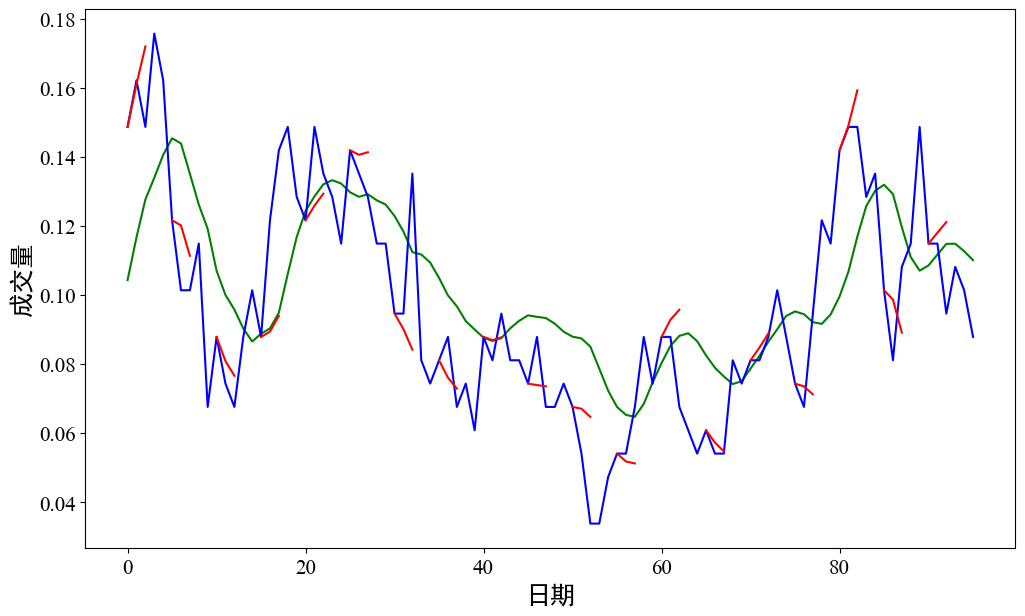

模型损失： 3.601981340276931e-05


In [12]:
if __name__ == '__main__':
    ## 超参数
    days_num = 5
    epoch = 20
    fea = 5
    batch_size = 16
    early_stop = 5
 
    ## 初始化模型
    model = Model(fea)
 
    ## 数据处理
    GD = GetData(data_path='./data/stock_price.csv')
    x_train, x_test, y_train, y_test = GD.process_data(days_num)   
    x_train = torch.tensor(x_train).float()
    x_test = torch.tensor(x_test).float()
    y_train = torch.tensor(y_train).float()
    y_test = torch.tensor(y_test).float()
    train_data = TensorDataset(x_train, y_train)
    train_dataLoader = DataLoader(train_data, batch_size = batch_size, drop_last = True)
    test_data = TensorDataset(x_test, y_test)
    test_dataLoader = DataLoader(test_data, batch_size = batch_size, drop_last = True)
    
    ## 损失函数、优化器
    loss_func = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_model(epoch, train_dataLoader, test_dataLoader)
    p, y, test_loss = test_model(test_dataLoader)
 
    #绘制折线图
    pred = [ele  for ele in p]
    data = [ele  for ele in y]
    plot_img(data, pred)

    #输出模型损失
    print('模型损失：',test_loss)